In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
# Contains the timepoint and celline for each sample in the 10plexes
# The "sample" column is the column name in the main dataset
plex1_meta = pd.read_csv("data/plex1_meta.csv")
plex2_meta = pd.read_csv("data/plex2_meta.csv")

# Load data (assuming CSVs are in the same relative path)
plex1 = pd.read_csv("data/10plex1.csv")
plex2 = pd.read_csv("data/10plex2.csv")

In [7]:
def run_pca_and_plot(df, metadata, title):
    """
    Helper function that standardizes the data, runs PCA, and plots the results. 
    
    Parameters
    ----------
    df : pandas.DataFrame
        The 10plex data.
    metadata : pandas.DataFrame
        Metadata dataframe.
    title : str
        Plot title. 
    """

    # We want the rows to be each sample and the columns to be the measurements
    # The sample column in our metadata denotes which columns are actual measurements
    X = df[metadata["sample"]].transpose()
    
    # Center and scale the data
    scaler = StandardScaler()

    # It is standard practice to perform a log2 transform on this type of biological data
    X_scaled = scaler.fit_transform(np.log2(X))

    # Run PCA
    pca = PCA(n_components=2)
    pca_features = pca.fit_transform(X_scaled)
    
    # Create a temp dataframe to plot the results and color by condition
    pca_df = pd.DataFrame(
        pca_features, 
        columns=['PC1', 'PC2'], 
        index=X.index
    ).reset_index()
    
    # Merge with metadata for coloring
    pca_df = pca_df.merge(metadata, left_on='index', right_on='sample')
    
    # Plot
    plt.figure(figsize=(5, 4))
    var_exp = pca.explained_variance_ratio_ * 100
    sns.scatterplot(
        data=pca_df, x='PC1', y='PC2', 
        hue='condition', s=100
    )
    plt.title(f"{title} - PCA")
    plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)")
    plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)")
    plt.show()

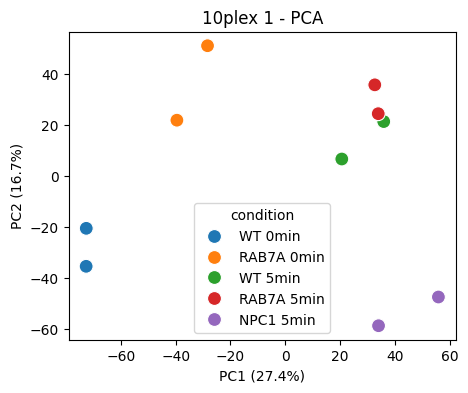

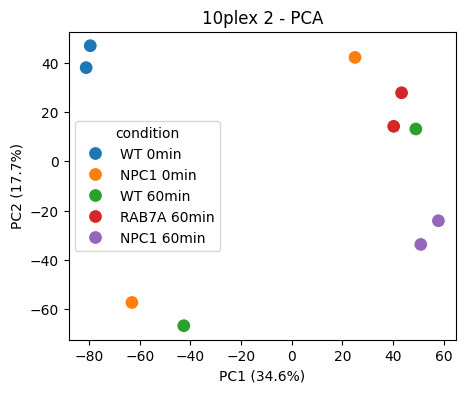

In [8]:
run_pca_and_plot(plex1, plex1_meta, "10plex 1")
run_pca_and_plot(plex2, plex2_meta, "10plex 2")

In 10plex 2, NPC1 and WT replicates are far from each other. time point or condition (sample) does not appear to be better represented by one PC than the other. 

In [15]:
corr_mat1 = plex1[plex1_meta["sample"]].corr()
corr_mat2 = plex2[plex2_meta["sample"]].corr()

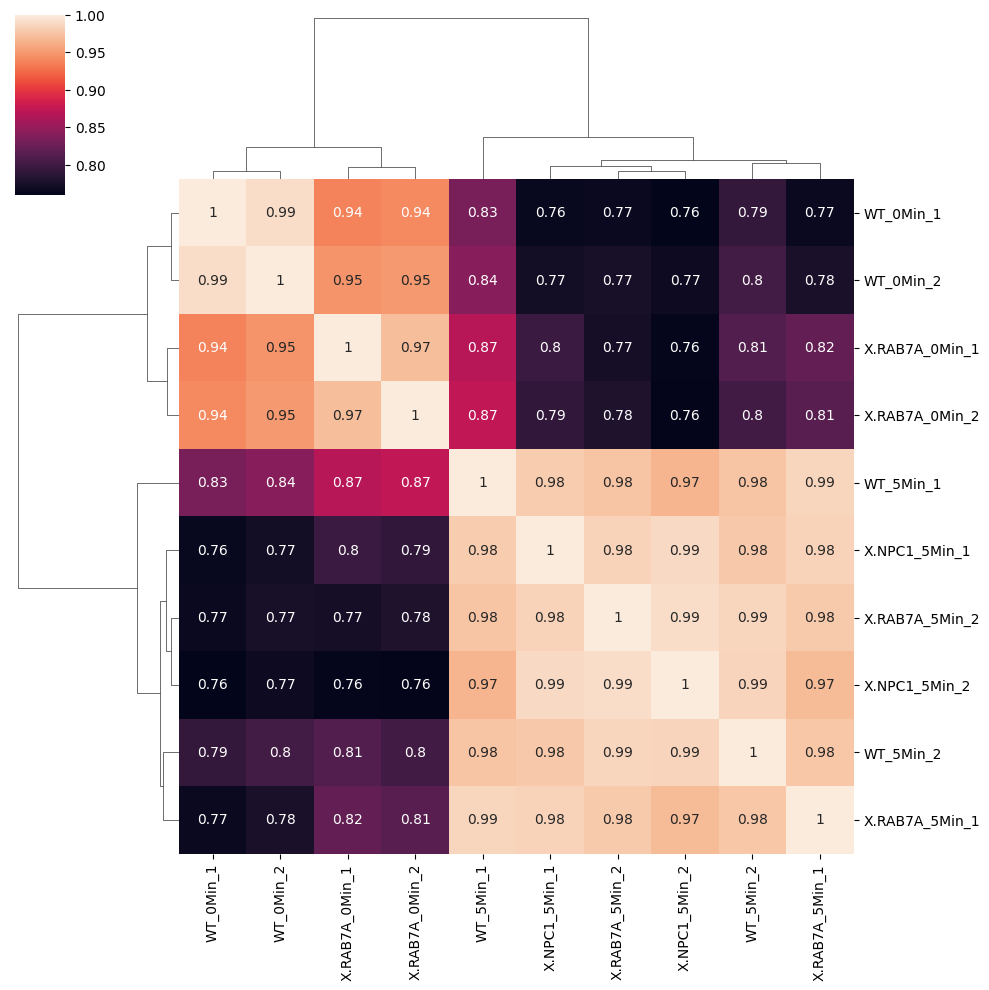

In [19]:
sns.clustermap(corr_mat1, annot=True)
plt.show()

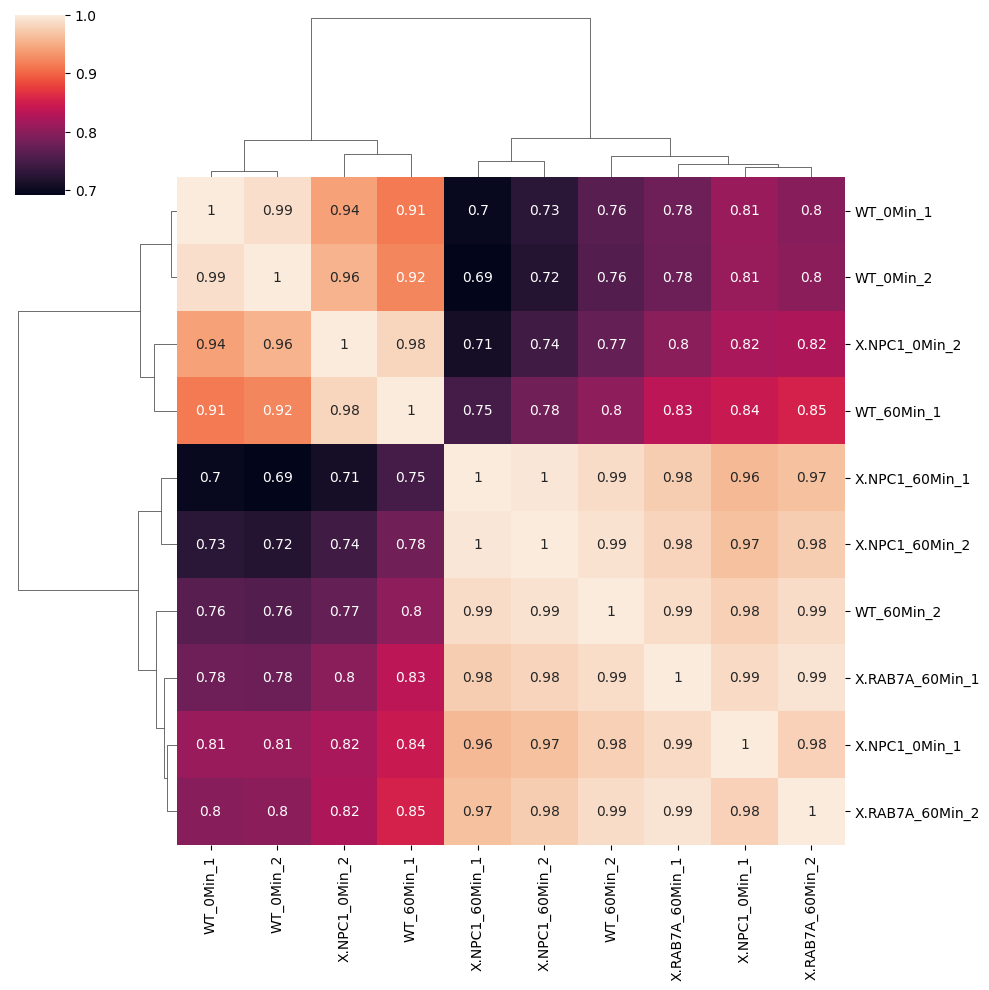

In [21]:
sns.clustermap(corr_mat2, annot=True)
plt.show()

Samples in both 10plexes primarily cluster by timepoint rather than condition and most replicates are adjacent. The exception is 10plex 2, where WT_60Min_1 clusters tightly with the 0 min samples while X.NPC1_0Min_1 clusters with the 60 min samples. Since each sample falls into the cluster matching the other's label, the most likely explanation is a label swap between WT_60Min_1 and X.NPC1_0Min_1.